sift
fast
orb


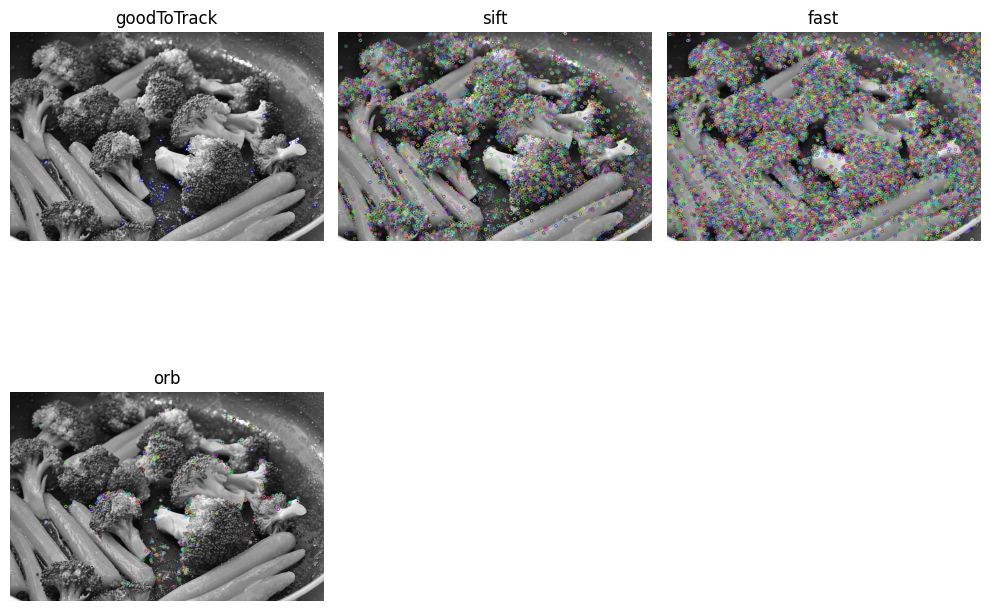

In [2]:
import cv2
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('./img3.jpg')
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
keyPoint = cv2.goodFeaturesToTrack(img1_gray, 25, 0.01, 10)
keyPoint = np.int64(keyPoint)
img2 = cv2.cvtColor(img1_gray, cv2.COLOR_GRAY2BGR)
for i in keyPoint:
    x, y = i.ravel()
    cv2.circle(img2, (x, y), 5, (0, 0, 255))
# cv2.imshow('goodToTrack', img2)
plt.figure(figsize=(10, 8))
plt.subplot(2, 3, 1)
plt.imshow(img2)
plt.title('goodToTrack')
plt.axis('off')

sift = cv2.xfeatures2d.SIFT_create()
# surf = cv2.xfeatures2d.SURF_create()
fast = cv2.FastFeatureDetector_create()
orb = cv2.ORB_create()
methods = [(sift, 'sift', 2),
        #    (surf, 'surf'),
           (fast, 'fast', 3),
           (orb, 'orb', 4)]
# for (method, name) in methods:
#     print(name)
#     keyPoint = method.detect(img1_gray, None)
#     res = cv2.drawKeypoints(img1_gray, keyPoint, img1)
#     cv2.imshow(name, res)

for (method, name, subplot_idx) in methods:
    print(name)
    keyPoint = method.detect(img1_gray, None)
    res = cv2.drawKeypoints(img1_gray, keyPoint, img1.copy())
    res_rgb = cv2.cvtColor(res, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2, 3, subplot_idx)
    plt.imshow(res_rgb)
    plt.title(name)
    plt.axis('off')

plt.tight_layout()
plt.show()